# Part 4: Feature Extraction

**Two tracks:**
1. **Handcrafted features** — MFCCs, spectral features, STFT, LOFAR, DEMON → classical ML input
2. **Deep features** — Log-mel spectrograms (128×128) → CNN input

**Input:** Processed audio from `shipsear_processed/` + `splits.json`  
**Output:** `features_train.npy`, `features_val.npy`, `features_test.npy`, `scaler.pkl`, spectrogram tensors

---
## 0. Imports & Configuration

In [3]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from scipy.signal import hilbert
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import librosa
import librosa.display
import soundfile as sf
from tqdm import tqdm

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

DATASET_ROOT   = r'/content/drive/MyDrive/ShipsEar Dataset/shipsear_5s_16k'
PROCESSED_ROOT = r'/content/drive/MyDrive/ShipsEar Dataset/shipsear_processed'
SPLITS_JSON    = 'splits.json'
OUTPUT_DIR     = 'features'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Audio config ─────────────────────────────────────────────────────────────
TARGET_SR      = 16000
SEGMENT_LEN_S  = 5.0
N_SAMPLES      = int(SEGMENT_LEN_S * TARGET_SR)   # 80000

# ── STFT / Mel config ────────────────────────────────────────────────────────
# Window: 25ms → samples
WIN_MS         = 25
HOP_MS         = 10
N_FFT          = int(WIN_MS  / 1000 * TARGET_SR)   # 400
HOP_LENGTH     = int(HOP_MS  / 1000 * TARGET_SR)   # 160
N_MELS         = 128
SPEC_HEIGHT    = 128
SPEC_WIDTH     = 128

# ── MFCC config ──────────────────────────────────────────────────────────────
N_MFCC         = 40

# ── LOFAR config ─────────────────────────────────────────────────────────────
LOFAR_NPERSEG  = 4096
LOFAR_NOVERLAP = 2048
LOFAR_TOP_K    = 10   # top-K spectral peaks

# ── DEMON config ─────────────────────────────────────────────────────────────
DEMON_FMIN     = 100  # Hz — bandpass before envelope extraction
DEMON_FMAX     = 5000
DEMON_N_PEAKS  = 5

CLASS_LABELS = {
    '0': 'A - Motorboats',
    '1': 'B - Mussel Boats',
    '2': 'C - Fishing Vessels',
    '3': 'D - Passengers/Ferries',
    '4': 'E - Ocean Liners/Tugboats'
}

print(f'N_FFT     : {N_FFT} samples ({WIN_MS} ms @ {TARGET_SR} Hz)')
print(f'HOP_LENGTH: {HOP_LENGTH} samples ({HOP_MS} ms)')
print(f'Time res  : {HOP_MS} ms/frame')
print(f'Freq res  : {TARGET_SR/N_FFT:.2f} Hz/bin')
print(f'N_MELS    : {N_MELS}')
print(f'Spec size : {SPEC_HEIGHT}×{SPEC_WIDTH}')

Mounted at /content/drive
N_FFT     : 400 samples (25 ms @ 16000 Hz)
HOP_LENGTH: 160 samples (10 ms)
Time res  : 10 ms/frame
Freq res  : 40.00 Hz/bin
N_MELS    : 128
Spec size : 128×128


---
## 1. Load Splits

In [4]:
# ── SECTION 1 FIX: Load & remap splits.json paths ────────────────────────────
import json, os, re

with open('splits.json') as f:
    splits = json.load(f)

base = splits['base_split']

# The paths look like: 'E:/MTQP/wjy_codes/shipsear_5s_16k/0/0_0/0_0_2.wav\t0'
# We need to:
#   1. Strip the \t<label> suffix (label is already in train_labels)
#   2. Strip the original machine prefix up to 'shipsear_5s_16k/'
#   3. Remap to your local DATASET_ROOT

DATASET_FOLDER = 'shipsear_5s_16k'

def remap_path(raw_path, dataset_root, dataset_folder=DATASET_FOLDER):
    # Strip tab+label suffix if present
    clean = raw_path.split('\t')[0].strip()
    # Normalise slashes
    clean = clean.replace('\\', '/')
    # Find the dataset folder and take everything after it
    idx = clean.lower().find(dataset_folder.lower())
    if idx != -1:
        # tail = '0/0_0/0_0_2.wav'
        tail = clean[idx + len(dataset_folder):].lstrip('/')
        return os.path.join(dataset_root, tail.replace('/', os.sep))
    return None

def remap_split(paths, dataset_root):
    remapped = []
    for p in paths:
        new_p = remap_path(p, dataset_root)
        remapped.append(new_p if (new_p and os.path.isfile(new_p)) else None)
    return remapped

train_paths  = remap_split(base['train'], DATASET_ROOT)
val_paths    = remap_split(base['val'],   DATASET_ROOT)
test_paths   = remap_split(base['test'],  DATASET_ROOT)
train_labels = base['train_labels']
val_labels   = base['val_labels']
test_labels  = base['test_labels']

# Filter None (any still-missing files)
def filter_valid(paths, labels):
    return zip(*[(p,l) for p,l in zip(paths,labels) if p is not None]) \
           if any(p is not None for p in paths) else ([], [])

train_paths, train_labels = [list(x) for x in filter_valid(train_paths, train_labels)]
val_paths,   val_labels   = [list(x) for x in filter_valid(val_paths,   val_labels)]
test_paths,  test_labels  = [list(x) for x in filter_valid(test_paths,  test_labels)]

print(f'Train : {len(train_paths)} segments  (resolved: {sum(p is not None for p in train_paths)})')
print(f'Val   : {len(val_paths)} segments')
print(f'Test  : {len(test_paths)} segments')
print(f'\nSample remapped path: {train_paths[0]}')
print(f'File exists: {os.path.isfile(train_paths[0])}')

Train : 1389 segments  (resolved: 1389)
Val   : 389 segments
Test  : 445 segments

Sample remapped path: /content/drive/MyDrive/ShipsEar Dataset/shipsear_5s_16k/0/0_0/0_0_2.wav
File exists: True


---
## 2. Audio Loading Utility

In [5]:
def load_audio(filepath, target_sr=TARGET_SR, target_len=N_SAMPLES):
    """
    Load audio, ensure mono, resample if needed, pad/trim to target_len.
    Returns numpy array of shape (target_len,).
    """
    y, sr = librosa.load(filepath, sr=target_sr, mono=True)
    # Pad if shorter, trim if longer
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    elif len(y) > target_len:
        y = y[:target_len]
    return y

# Quick test
y_test = load_audio(train_paths[0])
print(f'Loaded shape: {y_test.shape}  (expected {N_SAMPLES})')

Loaded shape: (80000,)  (expected 80000)


---
## 3. Handcrafted Feature Extractors
### 3.1 MFCC + Δ + ΔΔ (240-dim)

In [6]:
def extract_mfcc_features(y, sr=TARGET_SR):
    """
    Extract 40 MFCCs + delta + delta-delta.
    Aggregate: mean + std over time → 240-dim vector.
    """
    mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC,
                                  n_fft=N_FFT, hop_length=HOP_LENGTH)
    delta  = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)

    feats = []
    for mat in [mfcc, delta, delta2]:
        feats.extend(np.mean(mat, axis=1).tolist())  # 40
        feats.extend(np.std(mat,  axis=1).tolist())  # 40
    # Total: 3 × 80 = 240
    return np.array(feats, dtype=np.float32)

# Verify
f = extract_mfcc_features(y_test)
print(f'MFCC feature dim: {f.shape[0]}  (expected 240)')

MFCC feature dim: 240  (expected 240)


### 3.2 Spectral Features (24-dim)

In [7]:
def extract_spectral_features(y, sr=TARGET_SR):
    """
    Spectral centroid, bandwidth, rolloff, flatness, contrast (7 bands).
    Aggregate: mean + std → 24-dim vector.
    """
    centroid  = librosa.feature.spectral_centroid(y=y, sr=sr,
                    n_fft=N_FFT, hop_length=HOP_LENGTH)         # (1, T)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr,
                    n_fft=N_FFT, hop_length=HOP_LENGTH)         # (1, T)
    rolloff   = librosa.feature.spectral_rolloff(y=y, sr=sr,
                    n_fft=N_FFT, hop_length=HOP_LENGTH,
                    roll_percent=0.85)                           # (1, T)
    flatness  = librosa.feature.spectral_flatness(y=y,
                    n_fft=N_FFT, hop_length=HOP_LENGTH)         # (1, T)
    contrast  = librosa.feature.spectral_contrast(y=y, sr=sr,
                    n_fft=N_FFT, hop_length=HOP_LENGTH,
                    n_bands=6)                                   # (7, T)

    feats = []
    for mat in [centroid, bandwidth, rolloff, flatness]:  # 4 × (1,T)
        feats.append(np.mean(mat))
        feats.append(np.std(mat))
    for mat in [contrast]:                                 # 7 × (7,T)
        feats.extend(np.mean(mat, axis=1).tolist())        # 7
        feats.extend(np.std(mat,  axis=1).tolist())        # 7
    # Total: 4×2 + 7×2 = 8 + 14 = 22 ... pad to 24 with RMS + ZCR
    rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    feats.append(np.mean(rms)); feats.append(np.mean(zcr))
    # Total: 24
    return np.array(feats[:24], dtype=np.float32)

f = extract_spectral_features(y_test)
print(f'Spectral feature dim: {f.shape[0]}  (expected 24)')

Spectral feature dim: 24  (expected 24)


### 3.3 STFT Features (40-dim)

In [8]:
def extract_stft_features(y, sr=TARGET_SR):
    """
    STFT magnitude statistics:
    - Mean and std of each frequency bin over time → compressed via
      band averaging into 20 frequency bands (mean+std = 40-dim).
    """
    D = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH,
                             window='hann'))  # (N_FFT//2+1, T)
    D_db = librosa.amplitude_to_db(D, ref=np.max)

    # Compress into 20 frequency bands (mean over bins within band)
    n_bins  = D_db.shape[0]
    n_bands = 20
    band_means = []
    band_stds  = []
    indices = np.array_split(np.arange(n_bins), n_bands)
    for idx in indices:
        band_slice = D_db[idx, :]          # (band_size, T)
        band_means.append(np.mean(band_slice))
        band_stds.append(np.std(band_slice))

    feats = np.array(band_means + band_stds, dtype=np.float32)  # 40
    return feats

f = extract_stft_features(y_test)
print(f'STFT feature dim: {f.shape[0]}  (expected 40)')

STFT feature dim: 40  (expected 40)


### 3.4 LOFAR Spectral Lines (20-dim)

In [9]:
def extract_lofar_features(y, sr=TARGET_SR, top_k=LOFAR_TOP_K):
    """
    LOFAR (Low-Frequency Analysis and Recording):
    High-resolution narrowband PSD via Welch's method.
    Identifies top-K spectral peaks (engine harmonic lines).
    Returns: [peak_freq_1..K, peak_amp_1..K] → 2×K dim vector.
    """
    freqs, psd = signal.welch(y, fs=sr,
                               nperseg=LOFAR_NPERSEG,
                               noverlap=LOFAR_NOVERLAP,
                               window='hann')
    psd_db = 10 * np.log10(psd + 1e-12)

    # Find peaks using scipy
    from scipy.signal import find_peaks
    peaks, props = find_peaks(psd_db, height=np.percentile(psd_db, 75),
                              distance=5)

    # Sort peaks by amplitude (descending) and take top-K
    if len(peaks) == 0:
        peak_freqs = np.zeros(top_k, dtype=np.float32)
        peak_amps  = np.zeros(top_k, dtype=np.float32)
    else:
        peak_amps_all  = psd_db[peaks]
        sort_idx       = np.argsort(peak_amps_all)[::-1]
        peaks_sorted   = peaks[sort_idx]
        # Pad or trim to top_k
        peak_freqs = np.zeros(top_k, dtype=np.float32)
        peak_amps  = np.zeros(top_k, dtype=np.float32)
        n          = min(top_k, len(peaks_sorted))
        peak_freqs[:n] = freqs[peaks_sorted[:n]]
        peak_amps[:n]  = psd_db[peaks_sorted[:n]]

    # Normalise frequencies by Nyquist
    peak_freqs_norm = peak_freqs / (sr / 2.0)
    return np.concatenate([peak_freqs_norm, peak_amps]).astype(np.float32)  # 2*top_k

f = extract_lofar_features(y_test)
print(f'LOFAR feature dim: {f.shape[0]}  (expected {2*LOFAR_TOP_K})')

LOFAR feature dim: 20  (expected 20)


### 3.5 DEMON Spectrum Features (10-dim)

In [10]:
def extract_demon_features(y, sr=TARGET_SR, n_peaks=DEMON_N_PEAKS):
    """
    DEMON (Detection of Envelope Modulation on Noise):
    1. Bandpass filter to isolate cavitation noise (100–5000 Hz)
    2. Extract amplitude envelope via Hilbert transform
    3. Compute PSD of envelope (blade-rate frequencies appear as peaks)
    4. Return top-N peak frequencies + amplitudes → 2×N dim
    """
    from scipy.signal import butter, filtfilt, find_peaks

    # Step 1: Bandpass filter
    nyq  = sr / 2.0
    b, a = butter(4, [DEMON_FMIN / nyq, DEMON_FMAX / nyq], btype='band')
    y_bp = filtfilt(b, a, y)

    # Step 2: Hilbert envelope
    envelope = np.abs(hilbert(y_bp))

    # Step 3: PSD of envelope (Welch)
    freqs, psd = signal.welch(envelope, fs=sr,
                               nperseg=min(4096, len(envelope)//4),
                               noverlap=None, window='hann')
    psd_db = 10 * np.log10(psd + 1e-12)

    # Only look in 0.5–50 Hz for blade-rate (typical range)
    mask   = (freqs >= 0.5) & (freqs <= 50)
    f_sub  = freqs[mask]
    p_sub  = psd_db[mask]

    # Step 4: Find peaks
    peaks, _ = find_peaks(p_sub, height=np.percentile(p_sub, 60), distance=3)
    peak_freqs = np.zeros(n_peaks, dtype=np.float32)
    peak_amps  = np.zeros(n_peaks, dtype=np.float32)

    if len(peaks) > 0:
        sort_idx = np.argsort(p_sub[peaks])[::-1]
        n        = min(n_peaks, len(peaks))
        peak_freqs[:n] = f_sub[peaks[sort_idx[:n]]]
        peak_amps[:n]  = p_sub[peaks[sort_idx[:n]]]

    # Normalise frequencies by max DEMON freq (50 Hz)
    peak_freqs_norm = peak_freqs / 50.0
    return np.concatenate([peak_freqs_norm, peak_amps]).astype(np.float32)  # 2*n_peaks

f = extract_demon_features(y_test)
print(f'DEMON feature dim: {f.shape[0]}  (expected {2*DEMON_N_PEAKS})')

DEMON feature dim: 10  (expected 10)


### 3.6 Full Feature Vector Assembly

In [11]:
FEATURE_GROUPS = {
    'mfcc'     : extract_mfcc_features,       # 240
    'spectral' : extract_spectral_features,   # 24
    'stft'     : extract_stft_features,       # 40
    'lofar'    : extract_lofar_features,      # 20
    'demon'    : extract_demon_features,      # 10
}
FEATURE_DIMS = {'mfcc':240, 'spectral':24, 'stft':40, 'lofar':20, 'demon':10}
TOTAL_DIM    = sum(FEATURE_DIMS.values())   # 334

def extract_all_features(y, sr=TARGET_SR):
    """
    Extract all 5 feature groups and concatenate into one vector.
    Returns dict of individual groups + 'all' (concatenated).
    """
    groups = {name: fn(y, sr) for name, fn in FEATURE_GROUPS.items()}
    groups['all'] = np.concatenate(list(groups.values()))
    return groups

# Verify
sample_feats = extract_all_features(y_test)
print('Feature vector dimensions:')
for name, vec in sample_feats.items():
    print(f'  {name:10s}: {vec.shape[0]}')

Feature vector dimensions:
  mfcc      : 240
  spectral  : 24
  stft      : 40
  lofar     : 20
  demon     : 10
  all       : 334


---
## 4. Extract Features for All Splits

In [12]:
def extract_split(paths, labels, desc=''):
    """
    Extract handcrafted features for a list of audio files.
    Returns:
        X_all   : (N, TOTAL_DIM) full feature matrix
        X_groups: dict of group-specific (N, dim) matrices
        y       : (N,) integer label array
    """
    X_groups = {name: [] for name in FEATURE_GROUPS}
    y_out = []
    failed = 0

    for fpath, label in tqdm(zip(paths, labels), total=len(paths), desc=desc):
        try:
            audio  = load_audio(fpath)
            feats  = extract_all_features(audio)
            for name in FEATURE_GROUPS:
                X_groups[name].append(feats[name])
            y_out.append(int(label))
        except Exception as e:
            failed += 1

    print(f'  Done. Failed: {failed}')
    X_groups = {name: np.stack(vecs) for name, vecs in X_groups.items()}
    X_all    = np.concatenate(list(X_groups.values()), axis=1)
    y_arr    = np.array(y_out, dtype=np.int64)
    return X_all, X_groups, y_arr


print('Extracting TRAIN features...')
X_train, X_train_groups, y_train = extract_split(train_paths, train_labels, 'Train')

print('Extracting VAL features...')
X_val, X_val_groups, y_val = extract_split(val_paths, val_labels, 'Val')

print('Extracting TEST features...')
X_test, X_test_groups, y_test_labels = extract_split(test_paths, test_labels, 'Test')

print(f'\nShapes:')
print(f'  X_train : {X_train.shape}  y_train: {y_train.shape}')
print(f'  X_val   : {X_val.shape}  y_val  : {y_val.shape}')
print(f'  X_test  : {X_test.shape}  y_test : {y_test_labels.shape}')

Extracting TRAIN features...


Train: 100%|██████████| 1389/1389 [19:01<00:00,  1.22it/s]


  Done. Failed: 0
Extracting VAL features...


Val: 100%|██████████| 389/389 [05:20<00:00,  1.21it/s]


  Done. Failed: 0
Extracting TEST features...


Test: 100%|██████████| 445/445 [06:00<00:00,  1.24it/s]

  Done. Failed: 0

Shapes:
  X_train : (1389, 334)  y_train: (1389,)
  X_val   : (389, 334)  y_val  : (389,)
  X_test  : (445, 334)  y_test : (445,)


---
## 5. Standardise & Save Handcrafted Features

In [13]:
# Fit scaler on TRAINING SET ONLY — apply to val and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Save feature arrays
np.save(os.path.join(OUTPUT_DIR, 'features_train.npy'), X_train_scaled)
np.save(os.path.join(OUTPUT_DIR, 'features_val.npy'),   X_val_scaled)
np.save(os.path.join(OUTPUT_DIR, 'features_test.npy'),  X_test_scaled)
np.save(os.path.join(OUTPUT_DIR, 'labels_train.npy'),   y_train)
np.save(os.path.join(OUTPUT_DIR, 'labels_val.npy'),     y_val)
np.save(os.path.join(OUTPUT_DIR, 'labels_test.npy'),    y_test_labels)

# Save individual group features (unscaled) for ablation study in Part 6
for name in FEATURE_GROUPS:
    np.save(os.path.join(OUTPUT_DIR, f'feat_{name}_train.npy'), X_train_groups[name])
    np.save(os.path.join(OUTPUT_DIR, f'feat_{name}_val.npy'),   X_val_groups[name])
    np.save(os.path.join(OUTPUT_DIR, f'feat_{name}_test.npy'),  X_test_groups[name])

# Save scaler
with open(os.path.join(OUTPUT_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print('Saved features:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, fname)) / 1024
    print(f'  {fname:35s}  {size:8.1f} KB')

print(f'\nFull feature vector dim : {X_train_scaled.shape[1]}')
print(f'  MFCC (40×2×3)        : 240')
print(f'  Spectral             :  24')
print(f'  STFT bands           :  40')
print(f'  LOFAR peaks          :  20')
print(f'  DEMON peaks          :  10')
print(f'  TOTAL                : {TOTAL_DIM}')

Saved features:
  feat_demon_test.npy                      17.5 KB
  feat_demon_train.npy                     54.4 KB
  feat_demon_val.npy                       15.3 KB
  feat_lofar_test.npy                      34.9 KB
  feat_lofar_train.npy                    108.6 KB
  feat_lofar_val.npy                       30.5 KB
  feat_mfcc_test.npy                      417.3 KB
  feat_mfcc_train.npy                    1302.3 KB
  feat_mfcc_val.npy                       364.8 KB
  feat_spectral_test.npy                   41.8 KB
  feat_spectral_train.npy                 130.3 KB
  feat_spectral_val.npy                    36.6 KB
  feat_stft_test.npy                       69.7 KB
  feat_stft_train.npy                     217.2 KB
  feat_stft_val.npy                        60.9 KB
  features_test.npy                       580.7 KB
  features_train.npy                     1812.3 KB
  features_val.npy                        507.6 KB
  labels_test.npy                           3.6 KB
  labels_train.

---
## 6. PCA 2D Scatter Plot of Feature Space

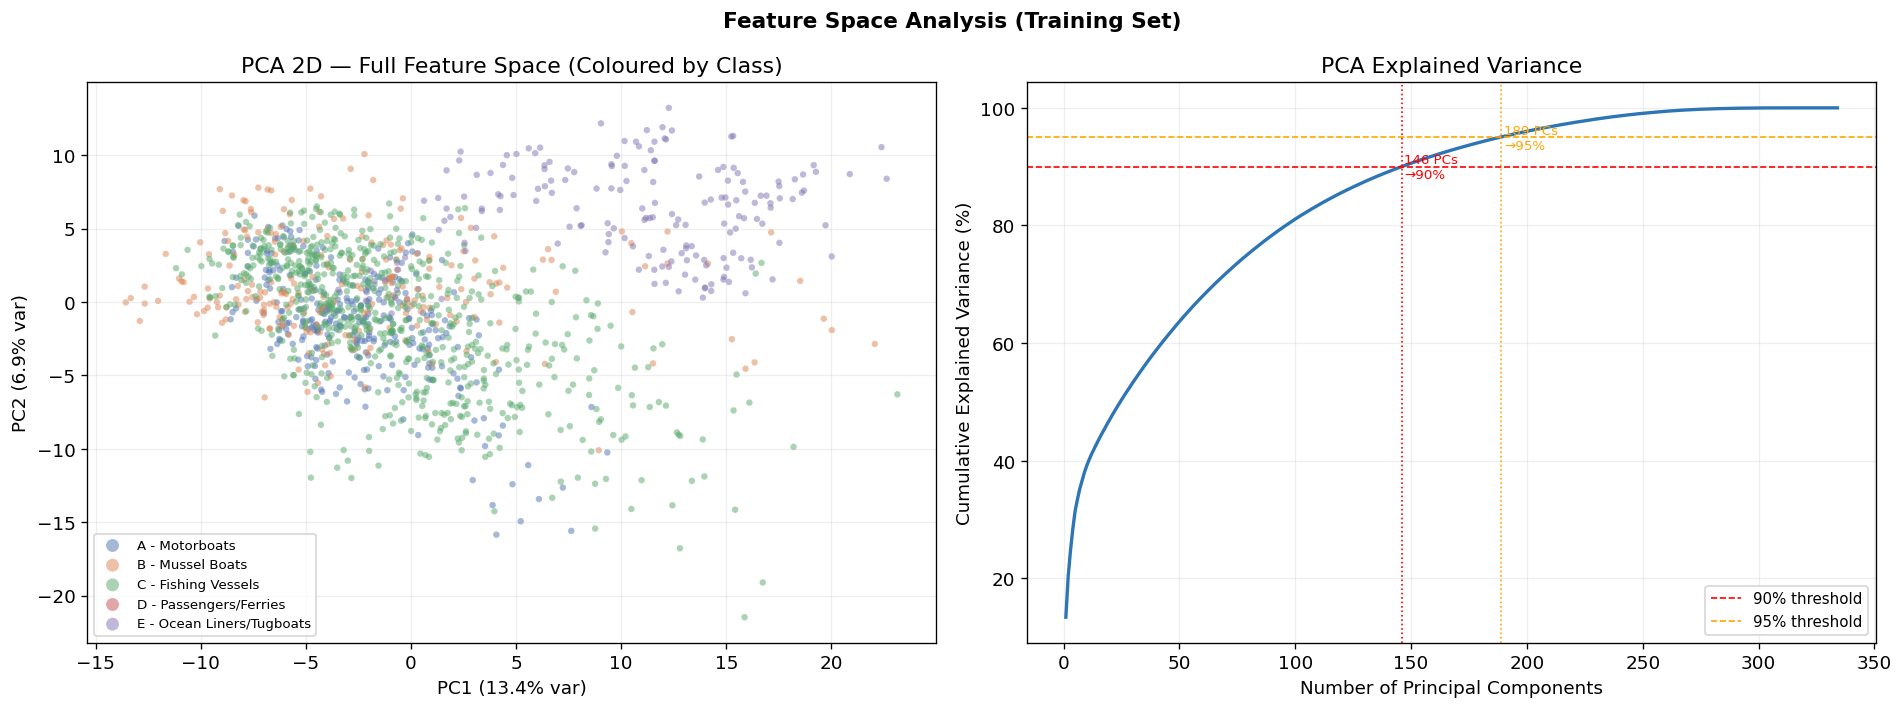

Saved: fig_pca_scatter.png
90% variance reached at 146 PCs, 95% at 189 PCs


In [14]:
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_train_scaled)
var    = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
ax = axes[0]
for cls_id, color in enumerate(PALETTE):
    mask = y_train == cls_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=CLASS_LABELS[str(cls_id)],
               alpha=0.5, s=15, edgecolors='none')
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% var)')
ax.set_title('PCA 2D — Full Feature Space (Coloured by Class)')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.2)

# Explained variance curve
pca_full = PCA(random_state=42).fit(X_train_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
ax2 = axes[1]
ax2.plot(range(1, len(cumvar)+1), cumvar*100, color='#2E75B6', linewidth=2)
ax2.axhline(90, color='red', linestyle='--', linewidth=1, label='90% threshold')
ax2.axhline(95, color='orange', linestyle='--', linewidth=1, label='95% threshold')
n90 = np.argmax(cumvar >= 0.90) + 1
n95 = np.argmax(cumvar >= 0.95) + 1
ax2.axvline(n90, color='red', linestyle=':', linewidth=1)
ax2.axvline(n95, color='orange', linestyle=':', linewidth=1)
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('PCA Explained Variance')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.2)
ax2.text(n90+1, 88, f'{n90} PCs\n→90%', fontsize=8, color='red')
ax2.text(n95+1, 93, f'{n95} PCs\n→95%', fontsize=8, color='orange')

plt.suptitle('Feature Space Analysis (Training Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pca_scatter.png', bbox_inches='tight')
plt.show()
print(f'Saved: fig_pca_scatter.png')
print(f'90% variance reached at {n90} PCs, 95% at {n95} PCs')

---
## 7. Per-Group Feature Visualisation

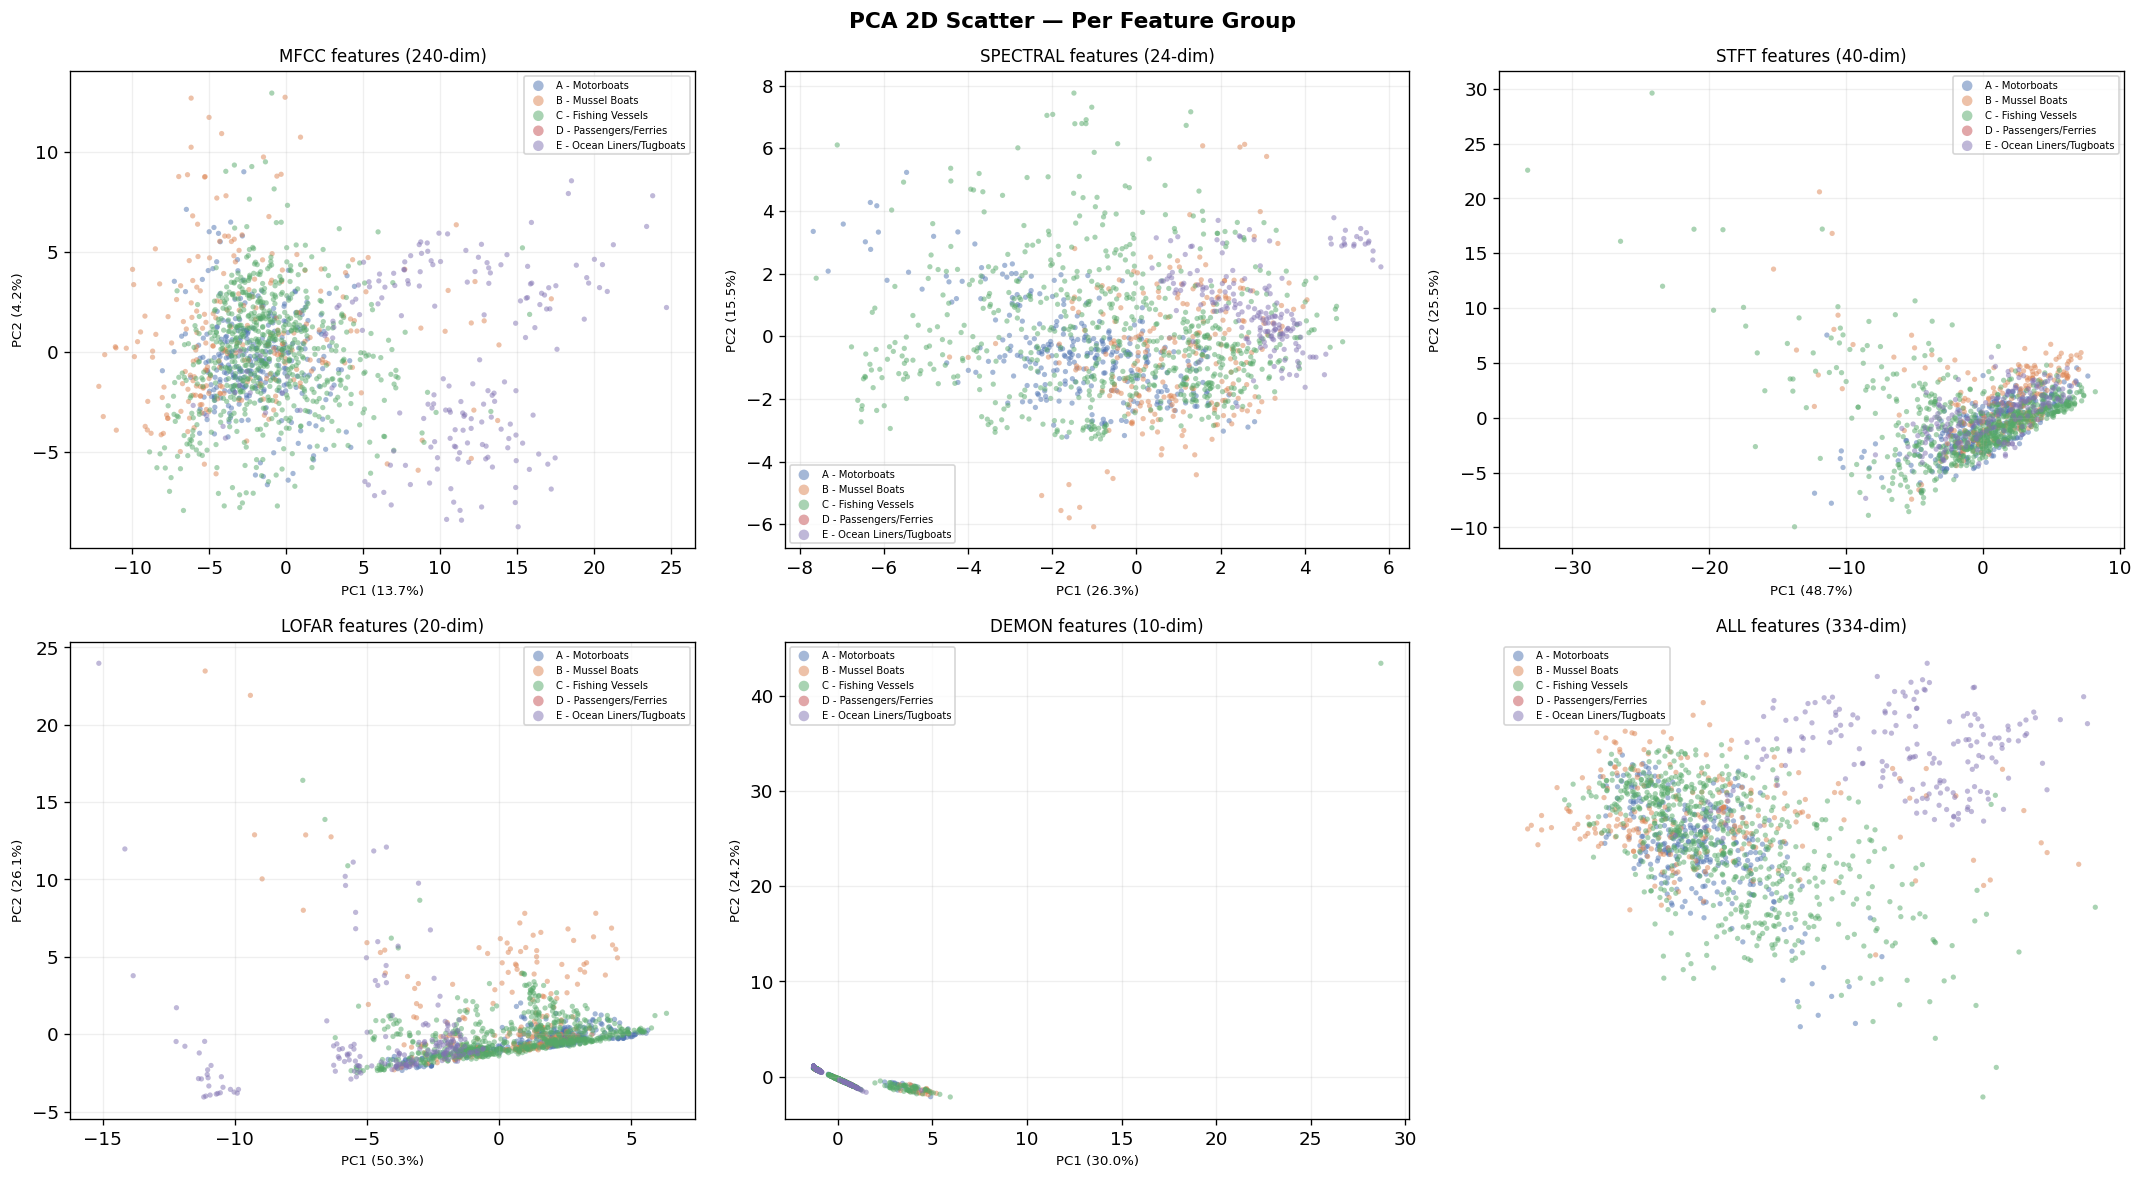

In [15]:
# PCA scatter per feature group
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

group_names = list(FEATURE_GROUPS.keys()) + ['all']
group_data  = {name: X_train_groups[name] for name in FEATURE_GROUPS}
group_data['all'] = X_train

for ax, name in zip(axes, group_names):
    X_g = group_data[name]
    sc  = StandardScaler().fit_transform(X_g)
    if sc.shape[1] >= 2:
        pca2  = PCA(n_components=2, random_state=42)
        X_2d  = pca2.fit_transform(sc)
        v     = pca2.explained_variance_ratio_
        for cls_id, color in enumerate(PALETTE):
            mask = y_train == cls_id
            ax.scatter(X_2d[mask,0], X_2d[mask,1], c=color,
                       label=CLASS_LABELS[str(cls_id)],
                       alpha=0.5, s=10, edgecolors='none')
        ax.set_xlabel(f'PC1 ({v[0]*100:.1f}%)', fontsize=8)
        ax.set_ylabel(f'PC2 ({v[1]*100:.1f}%)', fontsize=8)
    ax.set_title(f'{name.upper()} features ({FEATURE_DIMS.get(name, TOTAL_DIM)}-dim)', fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.grid(alpha=0.2)

axes[-1].axis('off')  # hide last empty subplot if present
plt.suptitle('PCA 2D Scatter — Per Feature Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pca_per_group.png', bbox_inches='tight')
plt.show()

---
## 8. Deep Features — Log-Mel Spectrograms
### 8.1 STFT & Mel Parameter Documentation

In [16]:
print('='*65)
print('DEEP FEATURE CONFIGURATION DOCUMENTATION')
print('='*65)
T_frames = 1 + (N_SAMPLES - N_FFT) // HOP_LENGTH
print(f"""
STFT Parameters:
  Window function   : Hann
  Window size       : {WIN_MS} ms = {N_FFT} samples  @ {TARGET_SR} Hz
  Hop size          : {HOP_MS} ms = {HOP_LENGTH} samples
  FFT size (n_fft)  : {N_FFT}
  Frequency bins    : {N_FFT//2 + 1}  (0 Hz to {TARGET_SR//2} Hz)
  Frequency res     : {TARGET_SR/N_FFT:.2f} Hz per bin
  Time resolution   : {HOP_MS} ms per frame
  Frames per 5s clip: {T_frames}

Mel Filterbank:
  N_MELS            : {N_MELS}
  Frequency range   : 0 Hz – {TARGET_SR//2} Hz
  Raw output shape  : ({N_MELS}, {T_frames})

Log Compression:
  S_dB = 10 × log10(S / ref)  where ref = max(S)
  Typical range: [-80, 0] dB

Resize to CNN input:
  ({N_MELS}, {T_frames}) → ({SPEC_HEIGHT}, {SPEC_WIDTH}) via bilinear interpolation
  Final tensor shape: (N, 1, {SPEC_HEIGHT}, {SPEC_WIDTH})
""")

DEEP FEATURE CONFIGURATION DOCUMENTATION

STFT Parameters:
  Window function   : Hann
  Window size       : 25 ms = 400 samples  @ 16000 Hz
  Hop size          : 10 ms = 160 samples
  FFT size (n_fft)  : 400
  Frequency bins    : 201  (0 Hz to 8000 Hz)
  Frequency res     : 40.00 Hz per bin
  Time resolution   : 10 ms per frame
  Frames per 5s clip: 498

Mel Filterbank:
  N_MELS            : 128
  Frequency range   : 0 Hz – 8000 Hz
  Raw output shape  : (128, 498)

Log Compression:
  S_dB = 10 × log10(S / ref)  where ref = max(S)
  Typical range: [-80, 0] dB

Resize to CNN input:
  (128, 498) → (128, 128) via bilinear interpolation
  Final tensor shape: (N, 1, 128, 128)



### 8.2 Log-Mel Spectrogram Extractor

In [17]:
from PIL import Image
import io

def extract_logmel(y, sr=TARGET_SR,
                   n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH,
                   height=SPEC_HEIGHT, width=SPEC_WIDTH):
    """
    Compute log-mel spectrogram and resize to (height, width).
    Returns numpy array of shape (height, width) with values in [-80, 0] dB.
    """
    S     = librosa.feature.melspectrogram(
                y=y, sr=sr, n_mels=n_mels,
                n_fft=n_fft, hop_length=hop_length,
                window='hann', fmin=0, fmax=sr//2
            )  # (n_mels, T)

    S_db  = librosa.power_to_db(S, ref=np.max)  # range: [-80, 0]

    # Resize to (height, width) using PIL bilinear interpolation
    # Convert to uint8 for PIL (map [-80,0] → [0,255])
    S_norm = (S_db - (-80)) / 80.0           # [0, 1]
    S_uint = (S_norm * 255).clip(0, 255).astype(np.uint8)
    img    = Image.fromarray(S_uint).resize((width, height), Image.BILINEAR)
    S_resized = np.array(img, dtype=np.float32)

    # Map back to dB range
    S_resized = (S_resized / 255.0) * 80.0 - 80.0
    return S_resized  # (height, width)

# Verify
spec_test = extract_logmel(y_test)
print(f'Spectrogram shape : {spec_test.shape}  (expected ({SPEC_HEIGHT}, {SPEC_WIDTH}))')
print(f'Value range       : [{spec_test.min():.1f}, {spec_test.max():.1f}] dB')

Spectrogram shape : (128, 128)  (expected (128, 128))
Value range       : [-55.2, -6.6] dB


### 8.3 5-Panel Log-Mel Gallery (1 per class)

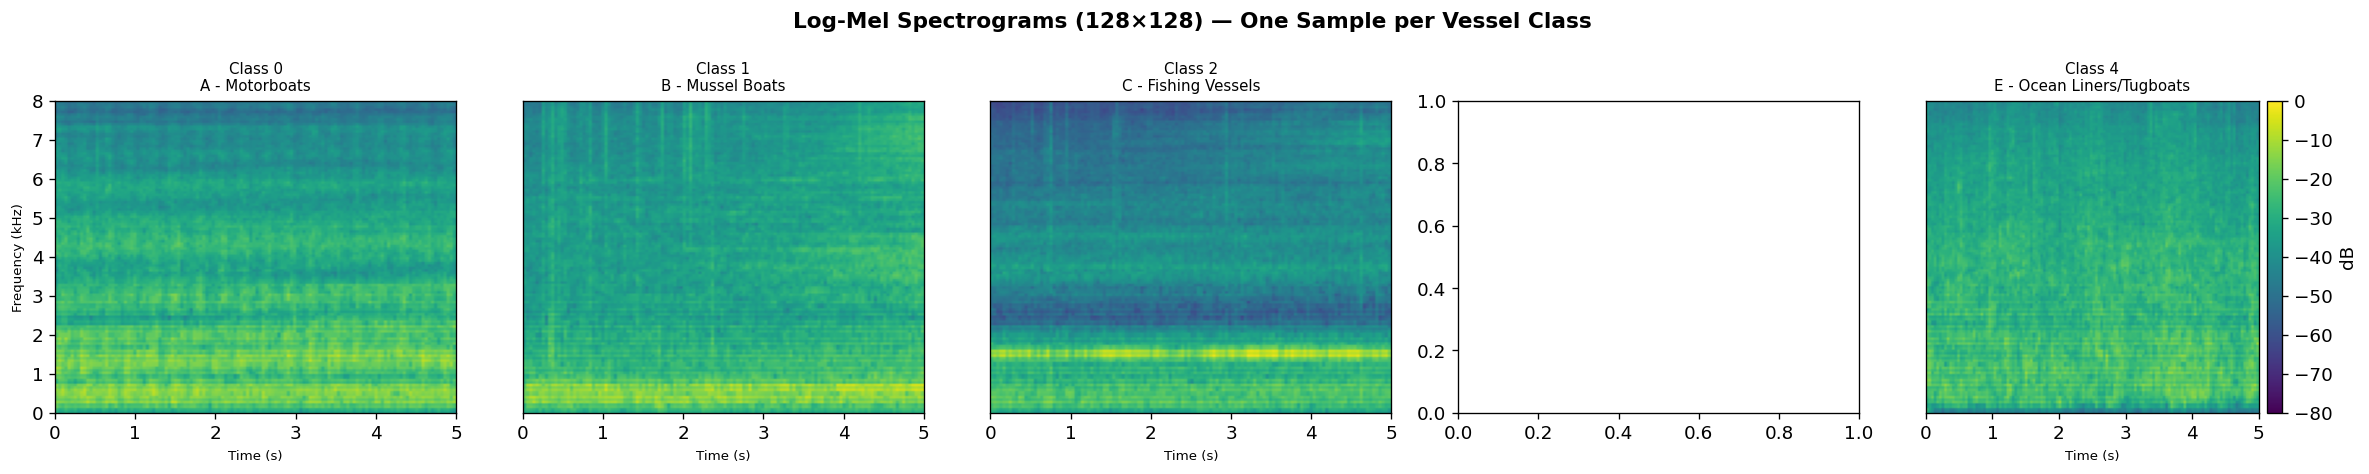

Saved: fig_logmel_gallery.png


In [18]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Pick one training file per class
for cls_id in range(5):
    idx = next((i for i, l in enumerate(train_labels) if int(l) == cls_id), None)
    if idx is None:
        continue
    y_audio = load_audio(train_paths[idx])
    S_db    = extract_logmel(y_audio)

    ax  = axes[cls_id]
    img = ax.imshow(S_db, aspect='auto', origin='lower',
                    cmap='viridis', vmin=-80, vmax=0,
                    extent=[0, SEGMENT_LEN_S, 0, TARGET_SR//2//1000])
    ax.set_title(f'Class {cls_id}\n{CLASS_LABELS[str(cls_id)]}', fontsize=9)
    ax.set_xlabel('Time (s)', fontsize=8)
    if cls_id == 0:
        ax.set_ylabel('Frequency (kHz)', fontsize=8)
    else:
        ax.set_yticks([])

fig.colorbar(img, ax=axes[-1], label='dB', pad=0.02)
plt.suptitle('Log-Mel Spectrograms (128×128) — One Sample per Vessel Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_logmel_gallery.png', bbox_inches='tight')
plt.show()
print('Saved: fig_logmel_gallery.png')

### 8.4 Extract & Save Spectrogram Tensors

In [19]:
def extract_spectrogram_split(paths, labels, desc=''):
    """
    Extract log-mel spectrograms for a split.
    Returns X: (N, 1, H, W) float32 tensor, y: (N,) int64.
    """
    X_list, y_list = [], []
    failed = 0
    for fpath, label in tqdm(zip(paths, labels), total=len(paths), desc=desc):
        try:
            audio = load_audio(fpath)
            spec  = extract_logmel(audio)              # (H, W)
            X_list.append(spec[np.newaxis, :, :])     # (1, H, W)
            y_list.append(int(label))
        except Exception as e:
            failed += 1
    print(f'  Done. Failed: {failed}')
    return np.stack(X_list).astype(np.float32), np.array(y_list, dtype=np.int64)


print('Extracting TRAIN spectrograms...')
X_spec_train, y_spec_train = extract_spectrogram_split(train_paths, train_labels, 'Train specs')

print('Extracting VAL spectrograms...')
X_spec_val, y_spec_val = extract_spectrogram_split(val_paths, val_labels, 'Val specs')

print('Extracting TEST spectrograms...')
X_spec_test, y_spec_test = extract_spectrogram_split(test_paths, test_labels, 'Test specs')

# Save
np.save(os.path.join(OUTPUT_DIR, 'spec_train.npy'), X_spec_train)
np.save(os.path.join(OUTPUT_DIR, 'spec_val.npy'),   X_spec_val)
np.save(os.path.join(OUTPUT_DIR, 'spec_test.npy'),  X_spec_test)
np.save(os.path.join(OUTPUT_DIR, 'spec_labels_train.npy'), y_spec_train)
np.save(os.path.join(OUTPUT_DIR, 'spec_labels_val.npy'),   y_spec_val)
np.save(os.path.join(OUTPUT_DIR, 'spec_labels_test.npy'),  y_spec_test)

print(f'\nSpectrogram tensor shapes:')
print(f'  Train : {X_spec_train.shape}  labels: {y_spec_train.shape}')
print(f'  Val   : {X_spec_val.shape}  labels: {y_spec_val.shape}')
print(f'  Test  : {X_spec_test.shape}  labels: {y_spec_test.shape}')
print(f'  Value range: [{X_spec_train.min():.1f}, {X_spec_train.max():.1f}] dB')

Extracting TRAIN spectrograms...


Train specs: 100%|██████████| 1389/1389 [00:28<00:00, 48.54it/s]


  Done. Failed: 0
Extracting VAL spectrograms...


Val specs: 100%|██████████| 389/389 [00:06<00:00, 64.00it/s]


  Done. Failed: 0
Extracting TEST spectrograms...


Test specs: 100%|██████████| 445/445 [00:13<00:00, 32.36it/s]


  Done. Failed: 0

Spectrogram tensor shapes:
  Train : (1389, 1, 128, 128)  labels: (1389,)
  Val   : (389, 1, 128, 128)  labels: (389,)
  Test  : (445, 1, 128, 128)  labels: (445,)
  Value range: [-80.0, -0.6] dB


### 8.5 PyTorch Dataset Class

In [20]:
try:
    import torch
    from torch.utils.data import Dataset, DataLoader

    class ShipsEarSpectrogramDataset(Dataset):
        """
        PyTorch Dataset for ShipsEar log-mel spectrogram tensors.

        Args:
            X : numpy array of shape (N, 1, H, W)
            y : numpy array of shape (N,) with integer class labels
            transform : optional transform applied to each spectrogram
        """
        def __init__(self, X: np.ndarray, y: np.ndarray, transform=None):
            self.X         = torch.from_numpy(X).float()
            self.y         = torch.from_numpy(y).long()
            self.transform = transform

        def __len__(self):
            return len(self.y)

        def __getitem__(self, idx):
            x = self.X[idx]  # (1, H, W)
            if self.transform:
                x = self.transform(x)
            return x, self.y[idx]

    # Verify dataset
    train_dataset = ShipsEarSpectrogramDataset(X_spec_train, y_spec_train)
    val_dataset   = ShipsEarSpectrogramDataset(X_spec_val,   y_spec_val)
    test_dataset  = ShipsEarSpectrogramDataset(X_spec_test,  y_spec_test)

    loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    batch_x, batch_y = next(iter(loader))

    print('PyTorch Dataset verified:')
    print(f'  Train dataset size  : {len(train_dataset)}')
    print(f'  Val   dataset size  : {len(val_dataset)}')
    print(f'  Test  dataset size  : {len(test_dataset)}')
    print(f'  Batch X shape       : {batch_x.shape}  (expect [32, 1, 128, 128])')
    print(f'  Batch y shape       : {batch_y.shape}')
    print(f'  Batch y labels      : {batch_y.unique().tolist()}')

except ImportError:
    print('PyTorch not installed — Dataset class defined but not tested.')
    print('Install with: pip install torch torchvision')

PyTorch Dataset verified:
  Train dataset size  : 1389
  Val   dataset size  : 389
  Test  dataset size  : 445
  Batch X shape       : torch.Size([32, 1, 128, 128])  (expect [32, 1, 128, 128])
  Batch y shape       : torch.Size([32])
  Batch y labels      : [0, 1, 2, 4]


---
## 9. Part 4 Summary

In [21]:
print('='*65)
print('PART 4 — COMPLETE SUMMARY')
print('='*65)
print(f"""
HANDCRAFTED FEATURES
--------------------
Feature group   Dim   Description
MFCC+Δ+ΔΔ      240   40 coeffs × 3 derivatives × (mean+std)
Spectral         24   Centroid, BW, Rolloff, Flatness, Contrast, RMS, ZCR
STFT bands       40   20 frequency bands × (mean+std) in dB
LOFAR peaks      20   Top-10 Welch PSD peaks (freq + amplitude)
DEMON peaks      10   Top-5 blade-rate envelope peaks (freq + amplitude)
─────────────────────
TOTAL           334   per segment

Scaling         : StandardScaler fit on TRAIN only
Saved           : features_train/val/test.npy  +  scaler.pkl
Group files     : feat_<name>_train/val/test.npy (for Part 6 ablation)

DEEP FEATURES (LOG-MEL SPECTROGRAMS)
-------------------------------------
Window          : {WIN_MS}ms Hann  →  {N_FFT} samples
Hop             : {HOP_MS}ms       →  {HOP_LENGTH} samples
Mel filterbanks : {N_MELS}
Log compression : power_to_db (ref=max) → [-80, 0] dB
Resize          : bilinear → {SPEC_HEIGHT}×{SPEC_WIDTH} pixels
Tensor shape    : (N, 1, {SPEC_HEIGHT}, {SPEC_WIDTH})
Saved           : spec_train/val/test.npy  +  spec_labels_*.npy

SAVED FIGURES
-------------
  fig_pca_scatter.png       PCA 2D + explained variance
  fig_pca_per_group.png     PCA per feature group
  fig_logmel_gallery.png    5-panel log-mel per class
""")
print('Part 4 complete ✓')

PART 4 — COMPLETE SUMMARY

HANDCRAFTED FEATURES
--------------------
Feature group   Dim   Description
MFCC+Δ+ΔΔ      240   40 coeffs × 3 derivatives × (mean+std)
Spectral         24   Centroid, BW, Rolloff, Flatness, Contrast, RMS, ZCR
STFT bands       40   20 frequency bands × (mean+std) in dB
LOFAR peaks      20   Top-10 Welch PSD peaks (freq + amplitude)
DEMON peaks      10   Top-5 blade-rate envelope peaks (freq + amplitude)
─────────────────────
TOTAL           334   per segment

Scaling         : StandardScaler fit on TRAIN only
Saved           : features_train/val/test.npy  +  scaler.pkl
Group files     : feat_<name>_train/val/test.npy (for Part 6 ablation)

DEEP FEATURES (LOG-MEL SPECTROGRAMS)
-------------------------------------
Window          : 25ms Hann  →  400 samples
Hop             : 10ms       →  160 samples
Mel filterbanks : 128
Log compression : power_to_db (ref=max) → [-80, 0] dB
Resize          : bilinear → 128×128 pixels
Tensor shape    : (N, 1, 128, 128)
Saved  